In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [63]:
!pip install -q scikit-image   # for CLAHE

import os, random, math, gc, warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from skimage import exposure             # CLAHE

from   albumentations import (
        HorizontalFlip, VerticalFlip, Rotate, ShiftScaleRotate,
        RandomCrop, RandomBrightnessContrast, Compose, OneOf
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from tensorflow.keras.metrics import AUC
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv2D, Dense, GlobalAveragePooling2D,
                                     Dropout)
from tensorflow.keras import layers, models, optimizers, callbacks
import math, time, numpy as np
from sklearn import metrics
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (ModelCheckpoint, ReduceLROnPlateau,
                                        EarlyStopping)

In [64]:
SEED            = 42
BATCH_SIZE      = 32
IMG_SIZE        = (224, 224)
DISEASE_COLS    = ['Atelectasis','Cardiomegaly','Consolidation','Edema','Effusion',
                   'Emphysema','Fibrosis','Hernia','Infiltration','Mass','No Finding',
                   'Nodule','Pleural_Thickening','Pneumonia','Pneumothorax']
ALPHA           = 1.0 

In [65]:
labels_df = pd.read_csv('/kaggle/input/nih-balanced-and-resized-chest-x-rays/new_labels.csv')
labels_df.head()

,Path,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000001_000.png,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
2,00000001_002.png,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,00000003_000.png,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [66]:
labels_df = labels_df.sample(n=5100, random_state=SEED).reset_index(drop=True)

BASE_DIR   = '/kaggle/input/nih-balanced-and-resized-chest-x-rays/resized_images/resized_images'   # <-- change if necessary
labels_df['filepath'] = labels_df['Path'].apply(lambda x: os.path.join(BASE_DIR, x))


In [67]:
labels_df[DISEASE_COLS] = labels_df[DISEASE_COLS].astype('int')

train_df, temp_df = train_test_split(
        labels_df,
        test_size=0.40,
        random_state=SEED,       
        shuffle=True)

val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=SEED,
        shuffle=True)

print(f'Train  : {len(train_df)}')
print(f'Val    : {len(val_df)}')
print(f'Test   : {len(test_df)}')

Train  : 3060
Val    : 1020
Test   : 1020


In [68]:
train_aug = ImageDataGenerator(
        rescale=1/255.,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True)

test_aug  = ImageDataGenerator(rescale=1/255.)

train_gen = train_aug.flow_from_dataframe(
        train_df, x_col='filepath', y_col=DISEASE_COLS,
        class_mode='raw', target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, shuffle=True, seed=SEED)

val_gen = test_aug.flow_from_dataframe(
        val_df,   x_col='filepath', y_col=DISEASE_COLS,
        class_mode='raw', target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, shuffle=False)

test_gen = test_aug.flow_from_dataframe(
        test_df,  x_col='filepath', y_col=DISEASE_COLS,
        class_mode='raw', target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, shuffle=False)

Found 3060 validated image filenames.
Found 1020 validated image filenames.
Found 1020 validated image filenames.


In [69]:
def build_model(alpha=1.0):
    base = MobileNetV2(weights='imagenet',
                       include_top=False,
                       input_shape=IMG_SIZE+(3,),
                       alpha=alpha)
    x = layers.GlobalAveragePooling2D()(base.output)
    out = layers.Dense(len(DISEASE_COLS), activation='sigmoid')(x)
    return models.Model(base.input, out), base

model, base_model = build_model(ALPHA)

In [70]:
base_model.trainable = False
model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy',
              metrics=[tf.keras.metrics.BinaryAccuracy(name='acc'),
                       tf.keras.metrics.AUC(multi_label=True, name='auc'),
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall')])

In [71]:
STEPS_1 = math.floor(train_gen.n / BATCH_SIZE)   # paper: floor division
es1 = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

t0 = time.time()
hist1 = model.fit(train_gen,
                  epochs=10,
                  steps_per_epoch=STEPS_1,
                  validation_data=val_gen,
                  callbacks=[es1])
print('Phase-1 done in %.1f min' % ((time.time()-t0)/60))

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 60s 496ms/step - acc: 0.8523 - auc: 0.5320 - loss: 0.4022 - precision: 0.0979 - recall: 0.0579 - val_acc: 0.8969 - val_auc: 0.6676 - val_loss: 0.3153 - val_precision: 0.4375 - val_recall: 0.0268
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - acc: 0.9063 - auc: 0.6094 - loss: 0.3076 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_acc: 0.8969 - val_auc: 0.6680 - val_loss: 0.3143 - val_precision: 0.4421 - val_recall: 0.0268
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 407ms/step - acc: 0.9008 - auc: 0.6675 - loss: 0.3038 - precision: 0.5894 - recall: 0.0251 - val_acc: 0.8989 - val_auc: 0.6985 - val_loss: 0.3060 - val_precision: 0.5514 - val_recall: 0.0651
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - acc: 0.9104 - auc: 0.6998 - loss: 0.2868 - precision: 0.6667 - recall: 0.0455 - val_acc: 0.8992 - val_auc: 0.6986 - val_loss: 0.3057 - val_precision: 0.5674 - val_recall: 0.0645
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 404ms/step - acc: 0.90

In [72]:
def get_metrics():
    return [tf.keras.metrics.BinaryAccuracy(name='acc'),
            tf.keras.metrics.AUC(multi_label=True, name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')]

In [73]:
base_model.trainable = True
model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=get_metrics())

STEPS_2 = STEPS_1 // 2
es2 = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

t1 = time.time()
hist2 = model.fit(train_gen,
                  initial_epoch=hist1.epoch[-1]+1,
                  epochs=hist1.epoch[-1]+1+15,
                  steps_per_epoch=STEPS_2,
                  validation_data=val_gen,
                  callbacks=[es2])
print('Phase-2 done in %.1f min' % ((time.time()-t1)/60))

Epoch 8/22
47/47 ━━━━━━━━━━━━━━━━━━━━ 85s 618ms/step - acc: 0.8938 - auc: 0.6225 - loss: 0.3335 - precision: 0.3037 - recall: 0.0374 - val_acc: 0.8970 - val_auc: 0.6988 - val_loss: 0.3143 - val_precision: 0.4813 - val_recall: 0.0824
Epoch 9/22
47/47 ━━━━━━━━━━━━━━━━━━━━ 33s 707ms/step - acc: 0.9030 - auc: 0.7018 - loss: 0.2930 - precision: 0.6641 - recall: 0.0511 - val_acc: 0.8990 - val_auc: 0.7033 - val_loss: 0.3136 - val_precision: 0.5352 - val_recall: 0.0971
Epoch 10/22
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - acc: 0.9146 - auc: 0.7557 - loss: 0.2517 - precision: 0.8298 - recall: 0.0579 - val_acc: 0.8992 - val_auc: 0.7035 - val_loss: 0.3129 - val_precision: 0.5432 - val_recall: 0.0964
Epoch 11/22
47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 473ms/step - acc: 0.9053 - auc: 0.7340 - loss: 0.2807 - precision: 0.6494 - recall: 0.0661 - val_acc: 0.8987 - val_auc: 0.7120 - val_loss: 0.3238 - val_precision: 0.5260 - val_recall: 0.1034
Epoch 12/22
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 432ms/step - acc: 0.9054 

In [74]:
model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=get_metrics())

es3 = callbacks.EarlyStopping(monitor='val_loss', patience=10)
t2 = time.time()
hist3 = model.fit(train_gen,
                  initial_epoch=hist2.epoch[-1]+1,
                  epochs=hist2.epoch[-1]+1+10,
                  steps_per_epoch=STEPS_1,
                  validation_data=val_gen,
                  callbacks=[es3])
print('Phase-3 done in %.1f min' % ((time.time()-t2)/60))

Epoch 14/23
95/95 ━━━━━━━━━━━━━━━━━━━━ 115s 634ms/step - acc: 0.9069 - auc: 0.7340 - loss: 0.2795 - precision: 0.7592 - recall: 0.0704 - val_acc: 0.8995 - val_auc: 0.7089 - val_loss: 0.3091 - val_precision: 0.5574 - val_recall: 0.0868
Epoch 15/23
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - acc: 0.8875 - auc: 0.6666 - loss: 0.3085 - precision: 0.5000 - recall: 0.0185 - val_acc: 0.8996 - val_auc: 0.7090 - val_loss: 0.3091 - val_precision: 0.5610 - val_recall: 0.0881
Epoch 16/23
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 419ms/step - acc: 0.9064 - auc: 0.7448 - loss: 0.2761 - precision: 0.7326 - recall: 0.0836 - val_acc: 0.9001 - val_auc: 0.7134 - val_loss: 0.3059 - val_precision: 0.5768 - val_recall: 0.0888
Epoch 17/23
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - acc: 0.8896 - auc: 0.7509 - loss: 0.3102 - precision: 0.5000 - recall: 0.0377 - val_acc: 0.9000 - val_auc: 0.7133 - val_loss: 0.3059 - val_precision: 0.5744 - val_recall: 0.0888
Epoch 18/23
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 419ms/step - acc: 0.9052

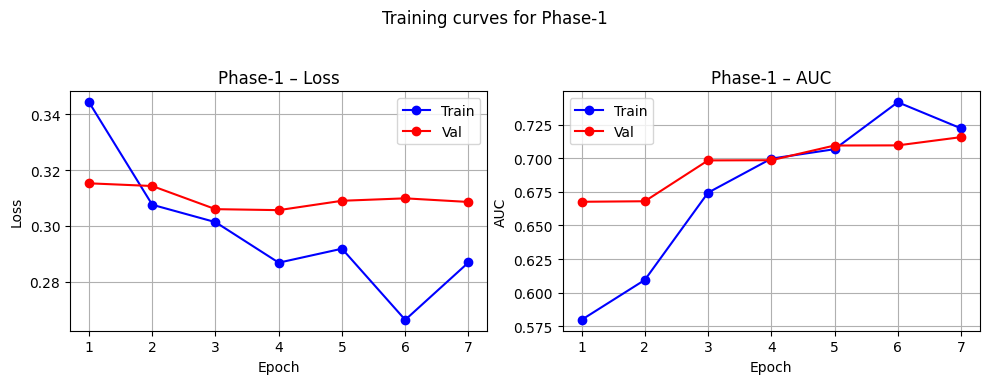

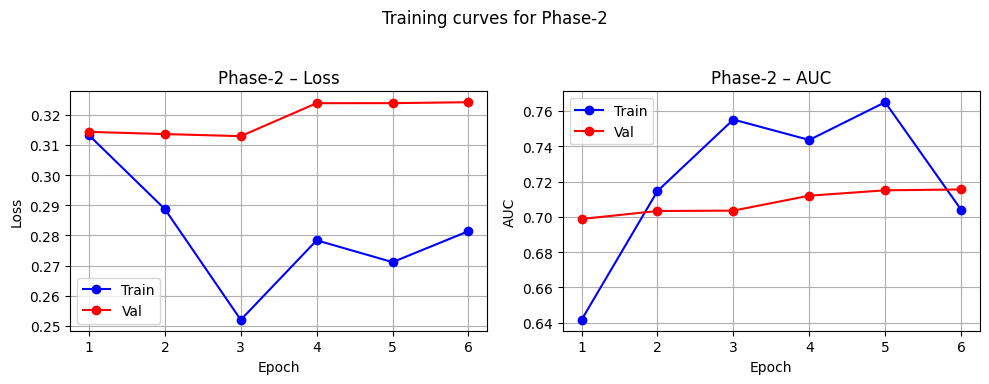

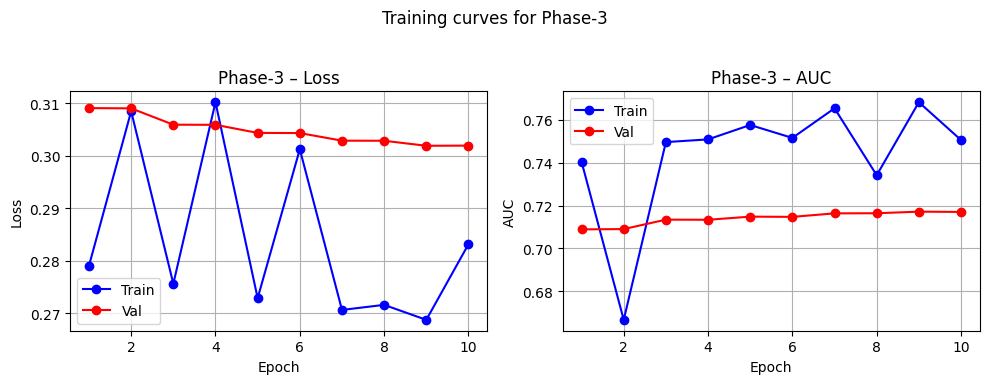

In [75]:
phase_histories = [hist1, hist2, hist3]
phase_names     = ['Phase-1', 'Phase-2', 'Phase-3']

for idx, (h, name) in enumerate(zip(phase_histories, phase_names), 1):
    epochs = range(1, len(h.history['loss']) + 1)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, h.history['loss'],     'bo-', label='Train')
    plt.plot(epochs, h.history['val_loss'], 'ro-', label='Val')
    plt.title(f'{name} – Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, h.history['auc'],     'bo-', label='Train')
    plt.plot(epochs, h.history['val_auc'], 'ro-', label='Val')
    plt.title(f'{name} – AUC')
    plt.xlabel('Epoch'); plt.ylabel('AUC')
    plt.legend(); plt.grid(True)

    plt.suptitle(f'Training curves for {name}')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])   
    plt.show()

In [76]:
LAST_CONV = 'Conv_1'

def preprocess_pipeline(path, size=(224,224)):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, size)
    img = np.stack([img]*3, axis=-1).astype('float32') / 255.0
    return img

In [77]:
def get_gradcam_heatmap(img_tensor, model, last_conv_layer=LAST_CONV):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_tensor)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]
    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(class_idx)

In [78]:
def overlay_heatmap(orig_gray, heatmap, alpha=0.45):
    heatmap = cv2.resize(heatmap, (orig_gray.shape[1], orig_gray.shape[0]))
    heatmap = np.uint8(255*heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)[..., ::-1]/255.0
    orig_rgb = np.stack([orig_gray]*3, -1)/255.0
    return np.clip(alpha*heatmap + (1-alpha)*orig_rgb, 0, 1)

In [79]:
def gradcam_for_row(row, model):
    img_path = row['filepath']        
    raw_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if raw_gray is None:
        raise FileNotFoundError(f"cv2.imread could not read {img_path}")

    tensor   = np.expand_dims(preprocess_pipeline(img_path), 0)
    heatmap, pred_idx = get_gradcam_heatmap(tensor, model)
    overlay = overlay_heatmap(raw_gray, heatmap)

    true_cls = row[DISEASE_COLS].idxmax()
    pred_cls = DISEASE_COLS[pred_idx]
    return overlay, true_cls, pred_cls

32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 236ms/step


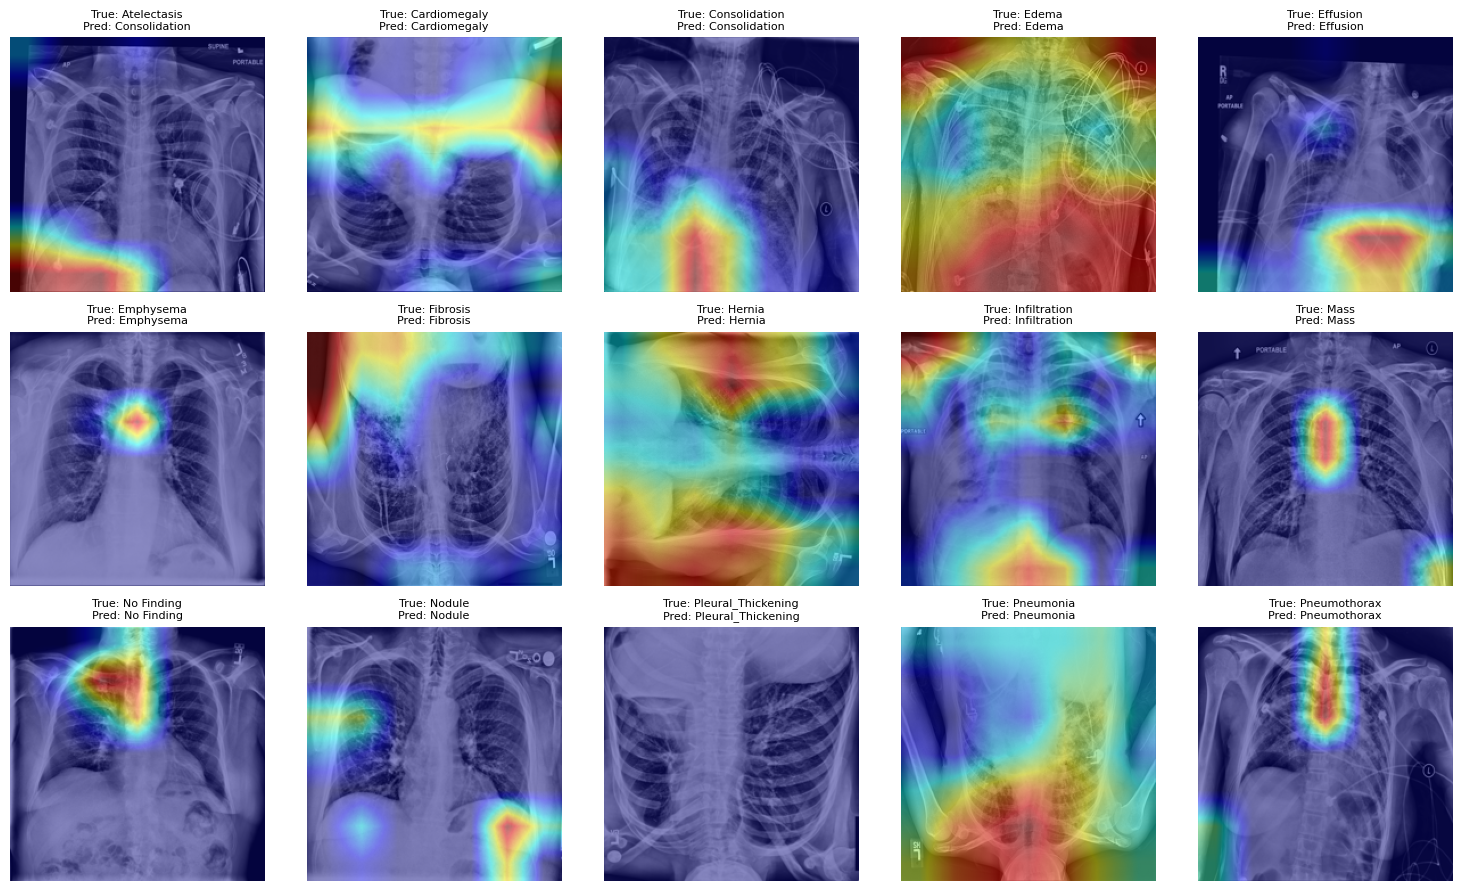

In [80]:
probs  = model.predict(test_gen, verbose=1)        
pred_y = np.argmax(probs, axis=1)

test_df = test_df.copy()
test_df['pred_idx']  = pred_y
test_df['pred_label'] = [DISEASE_COLS[i] for i in pred_y]
test_df['true_label'] = test_df[DISEASE_COLS].idxmax(axis=1)

samples = []
for cls in DISEASE_COLS:
    correct = test_df[(test_df['true_label'] == cls) &
                      (test_df['pred_label'] == cls)]
    row = (correct.sample(1, random_state=0) if len(correct) else
           test_df[test_df['true_label'] == cls].sample(1, random_state=0)).iloc[0]
    samples.append(row)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for ax, row in zip(axes, samples):
    overlay, t, p = gradcam_for_row(row, model)
    ax.imshow(overlay)
    ax.set_title(f"True: {t}\nPred: {p}", fontsize=8)
    ax.axis('off')

plt.tight_layout(); plt.show()

In [81]:
!pip -q install -U shap
import shap

In [ ]:
BG_MAX = 100
bg_paths = train_df.sample(min(BG_MAX, len(train_df)), random_state=0)['filepath']
background = np.stack([preprocess_pipeline(p) for p in bg_paths], axis=0) 

explain_rows = []
for cls in DISEASE_COLS:
    correct = test_df[(test_df['true_label'] == cls) & (test_df['pred_label'] == cls)]
    row = (correct if len(correct)
           else test_df[test_df['true_label'] == cls]).sample(1, random_state=0).iloc[0]
    explain_rows.append(row)


explain_imgs  = np.stack([preprocess_pipeline(r['filepath']) for r in explain_rows], 0)  # (15,224,224,3)
gray_original = [cv2.imread(r['filepath'], cv2.IMREAD_GRAYSCALE) for r in explain_rows]

masker     = shap.maskers.Image("inpaint_telea", (224, 224, 3))
explainer  = shap.Explainer(model, masker, output_names=DISEASE_COLS,
                            data=background)

shap_values = explainer(explain_imgs, max_evals=300) 

for cls_idx, cls_name in enumerate(DISEASE_COLS):
    print(f"\n=== {cls_name} ===")
    shap.image_plot([shap_values[cls_idx]], -explain_imgs,
                    labels=[cls_name])

Image 1  True:Atelectasis  Pred:Consolidation


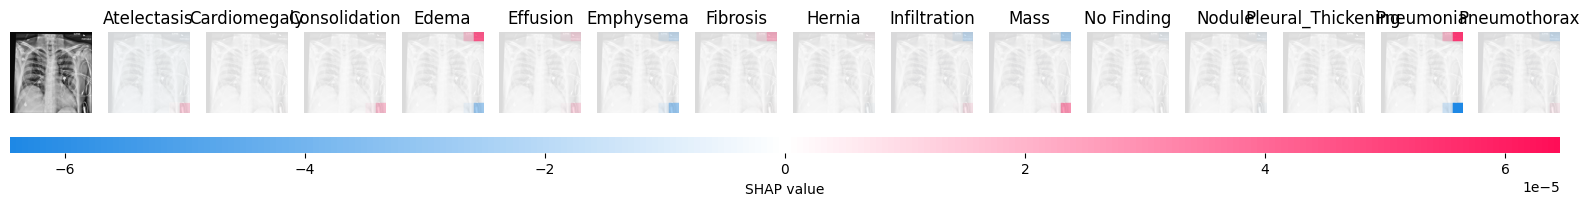

Image 2  True:Cardiomegaly  Pred:Cardiomegaly


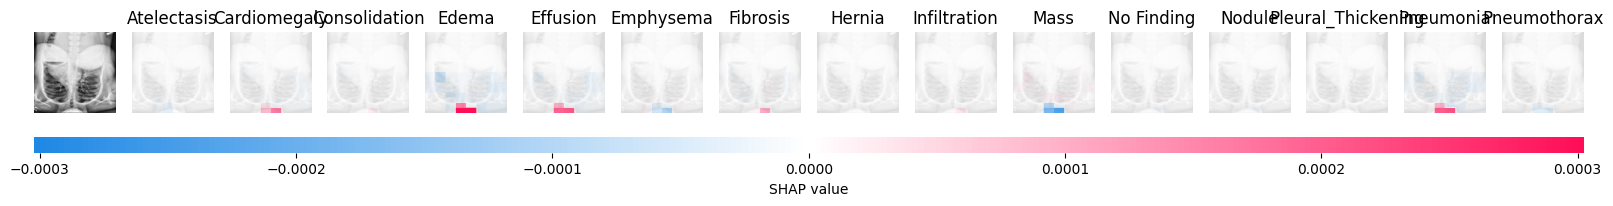

Image 3  True:Consolidation  Pred:Consolidation


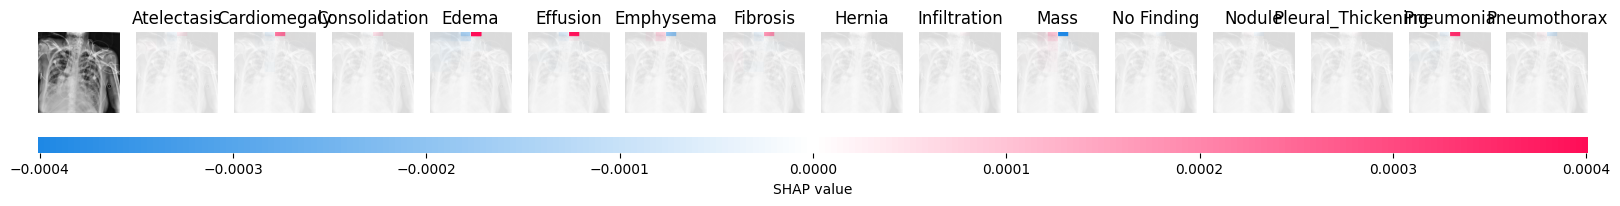

Image 4  True:Edema  Pred:Edema


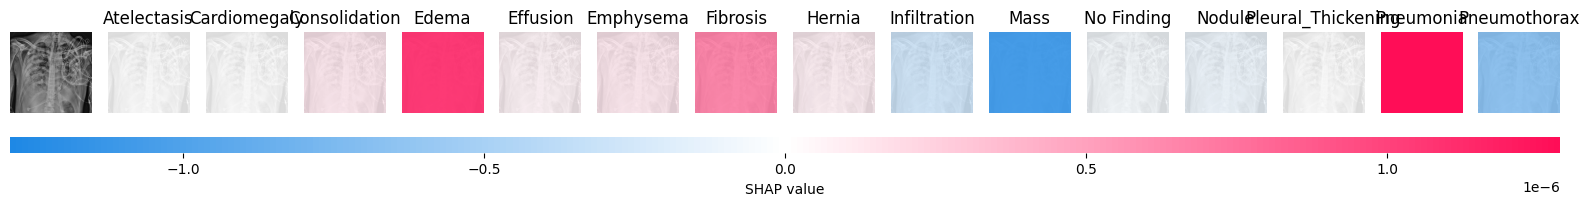

Image 5  True:Effusion  Pred:Effusion


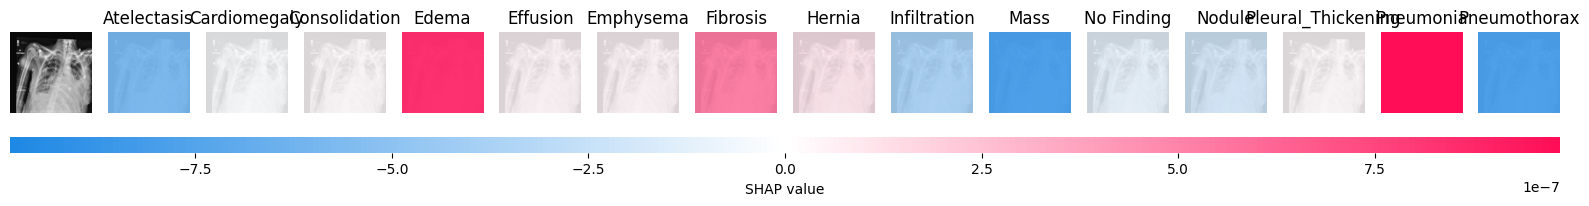

Image 6  True:Emphysema  Pred:Emphysema


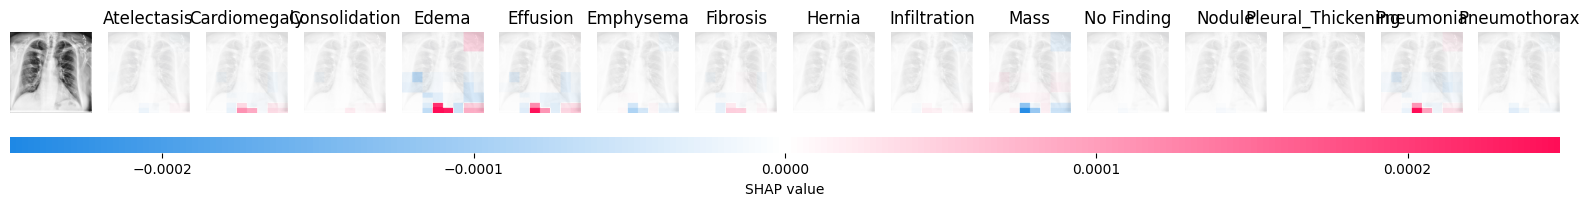

Image 7  True:Fibrosis  Pred:Fibrosis


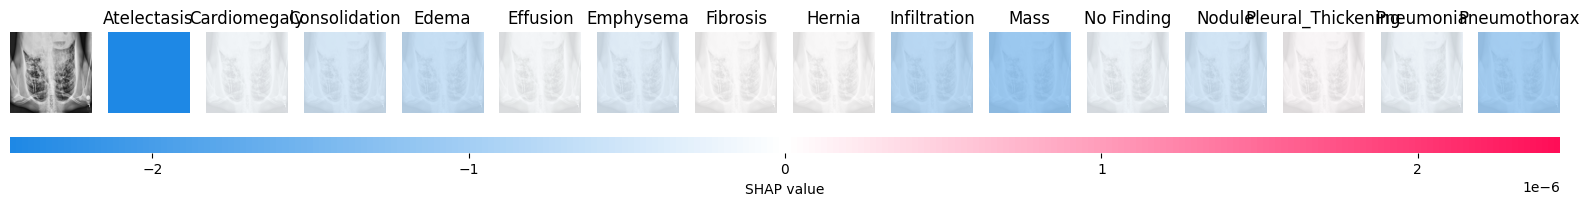

Image 8  True:Hernia  Pred:Hernia


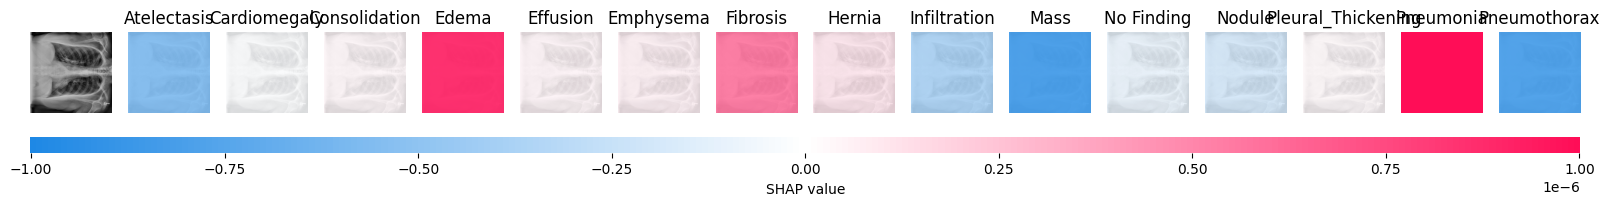

Image 9  True:Infiltration  Pred:Infiltration


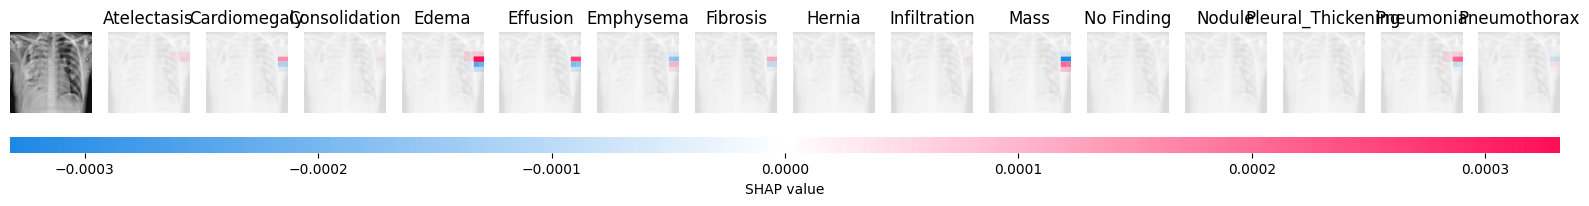

Image 10  True:Mass  Pred:Mass


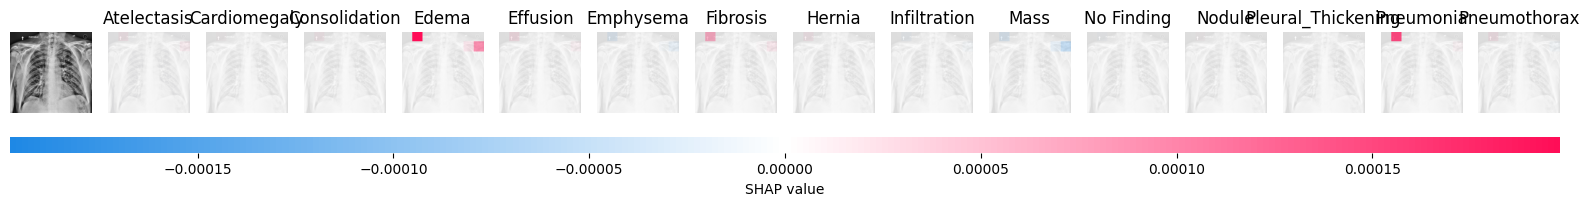

Image 11  True:No Finding  Pred:No Finding


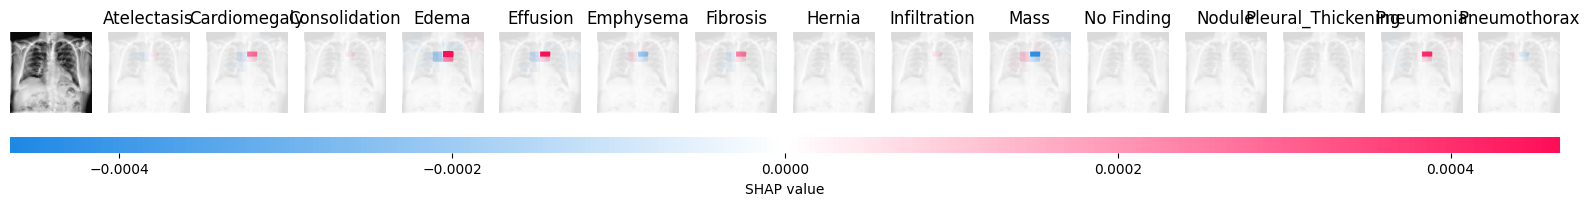

Image 12  True:Nodule  Pred:Nodule


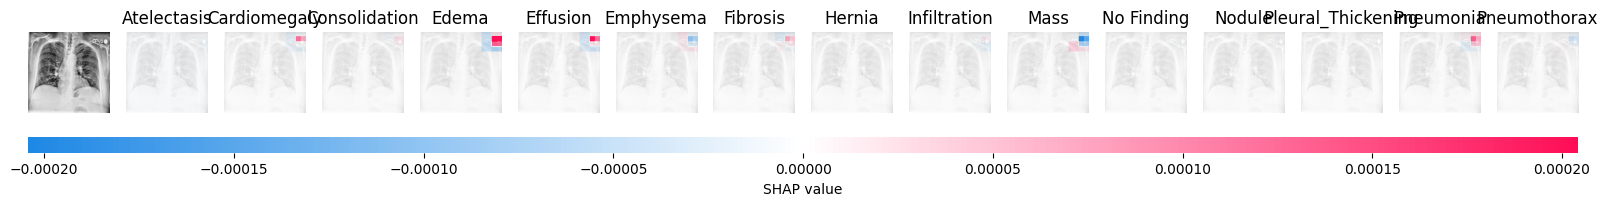

Image 13  True:Pleural_Thickening  Pred:Pleural_Thickening


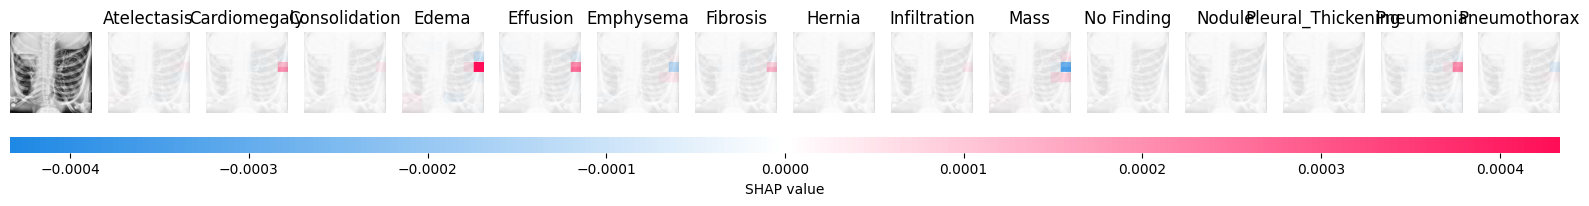

Image 14  True:Pneumonia  Pred:Pneumonia


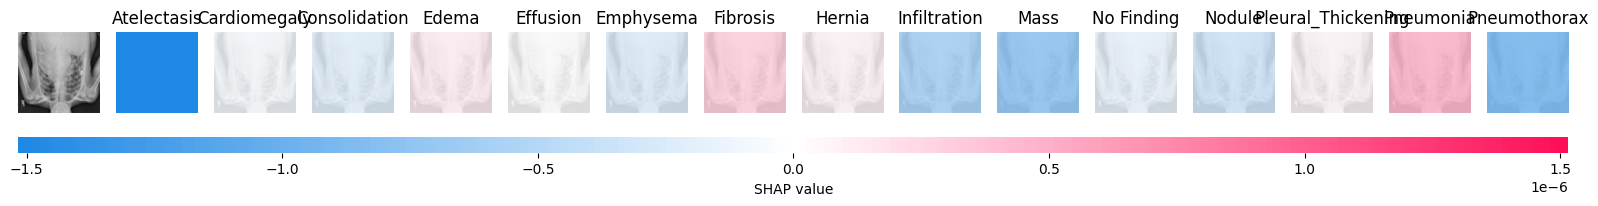

Image 15  True:Pneumothorax  Pred:Pneumothorax


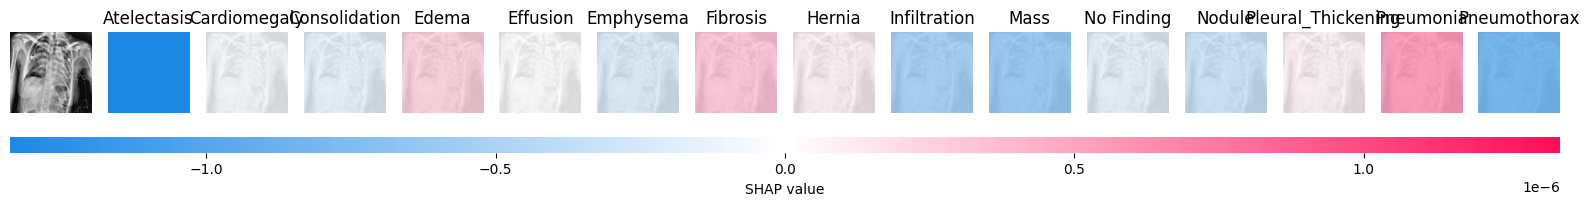

In [83]:
for i, (row, sv) in enumerate(zip(explain_rows, shap_values)):
    print(f"Image {i+1}  True:{row['true_label']}  Pred:{row['pred_label']}")
    shap.plots.image(sv, show=True) 

In [85]:
!pip -q install lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

  0%|          | 0/1000 [00:00<?, ?it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

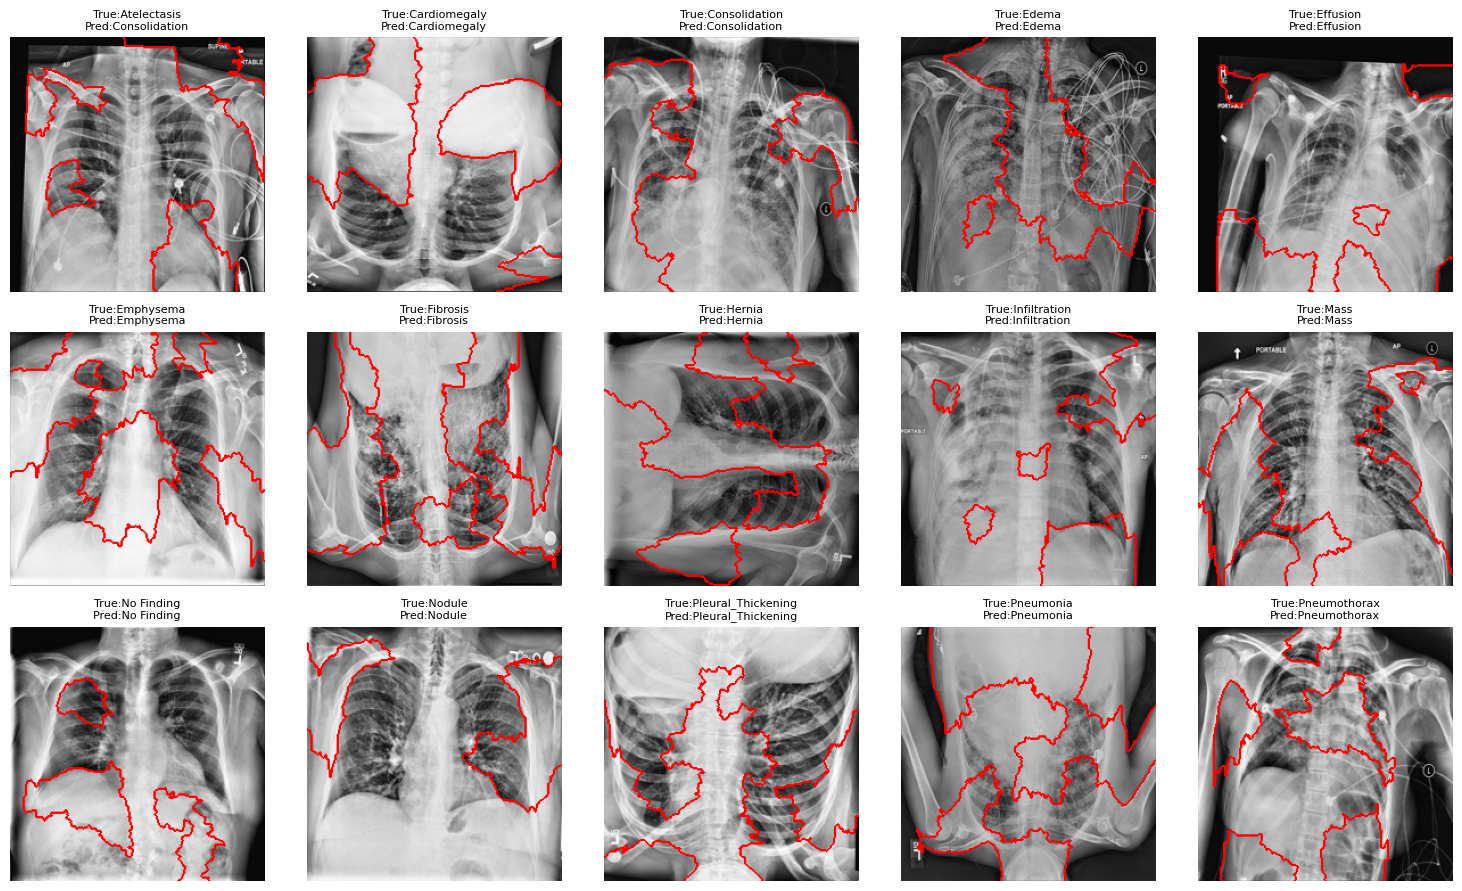

In [86]:
def lime_predict(imgs):
    imgs = np.array(imgs).astype('float32') / 255.0
    return model.predict(imgs)


explainer = lime_image.LimeImageExplainer(verbose=False)

explain_rows = []
for cls in DISEASE_COLS:
    correct = test_df[(test_df['true_label'] == cls) & (test_df['pred_label'] == cls)]
    row = (correct if len(correct)
           else test_df[test_df['true_label'] == cls]).sample(1, random_state=0).iloc[0]
    explain_rows.append(row)


fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for ax, row in zip(axes, explain_rows):
    orig = cv2.imread(row['filepath'], cv2.IMREAD_GRAYSCALE)
    orig_rgb = cv2.cvtColor(orig, cv2.COLOR_GRAY2RGB)

    explanation = explainer.explain_instance(
        image          = orig_rgb,
        classifier_fn  = lime_predict,
        top_labels     = 15,
        hide_color     = 0,
        num_samples    = 1000)         

    pred_vec = model.predict(np.expand_dims(preprocess_pipeline(row['filepath']),0))[0]
    cls_idx  = int(np.argmax(pred_vec))        
    cls_name = DISEASE_COLS[cls_idx]

    temp, mask = explanation.get_image_and_mask(
                    label        = cls_idx,
                    positive_only= True,       
                    num_features = 7,          
                    hide_rest    = False)

    blended = mark_boundaries(temp/255.0, mask, color=(1,0,0), mode='thick')

    ax.imshow(blended)
    ax.set_title(f"True:{row['true_label']}\nPred:{cls_name}", fontsize=8)
    ax.axis('off')

plt.tight_layout(); plt.show()

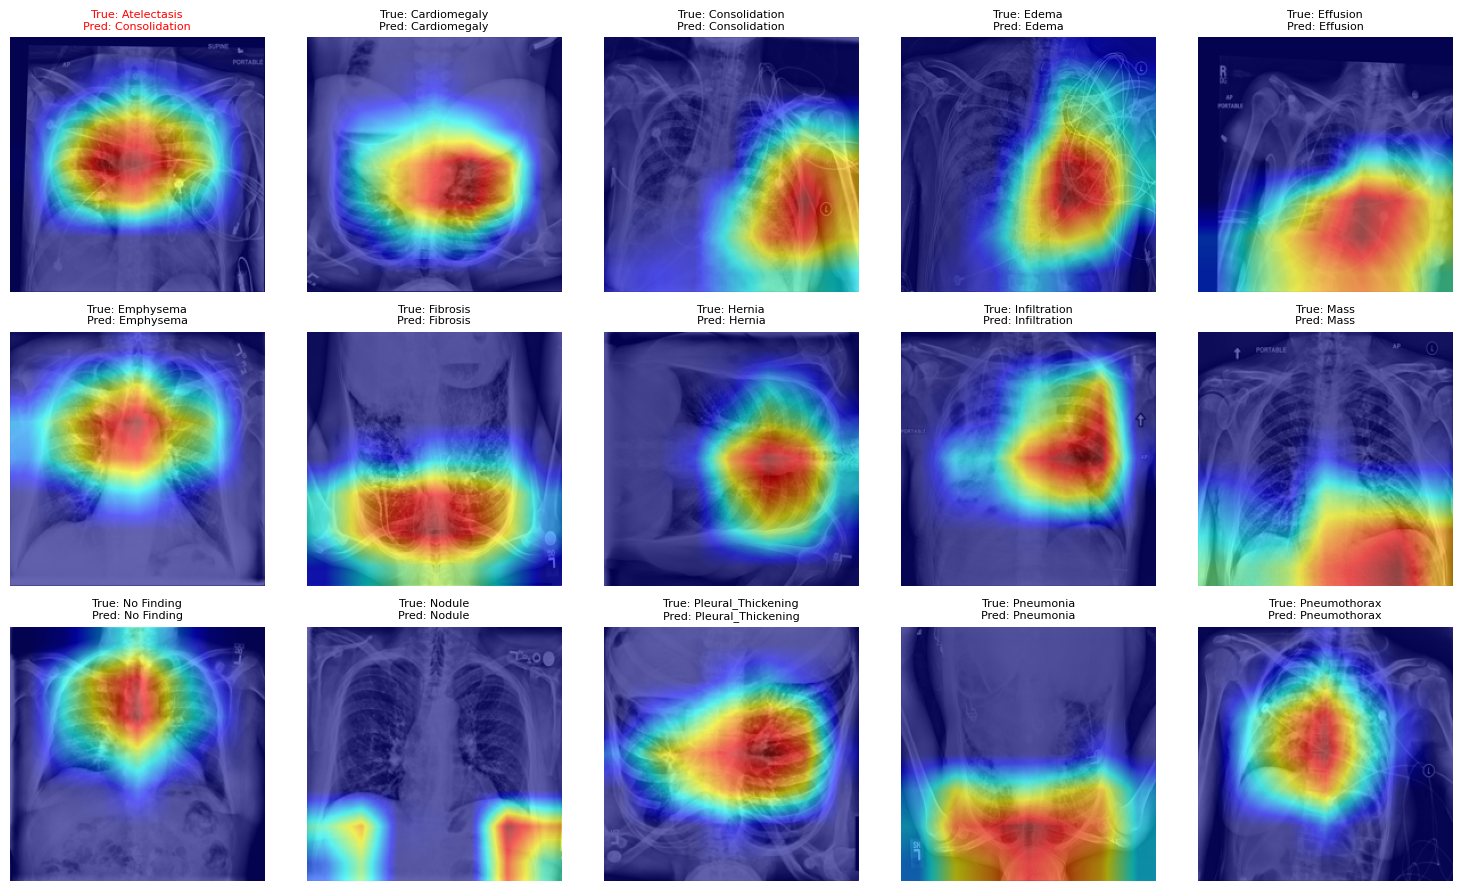

In [89]:
LAYER_NAME   = 'Conv_1'              
ALPHA_BLEND  = 0.6                   

feat_extractor = tf.keras.Model(
        inputs  = model.input,
        outputs = [model.get_layer(LAYER_NAME).output,   
                   model.output])                        
def eigen_cam(img_tensor):

    fmap, logits = feat_extractor(img_tensor, training=False)
    pred_idx     = int(tf.argmax(logits[0]))

    fmap = fmap[0].numpy()                     
    Hf, Wf, C = fmap.shape

    mat = fmap.reshape(-1, C)                    
    mat -= mat.mean(0, keepdims=True)           
    u, _, _ = np.linalg.svd(mat, full_matrices=False)
    cam = u[:, 0].reshape(Hf, Wf)                # (Hf,Wf)

    cam = np.maximum(cam, 0)
    cam = (cam - cam.min()) / (cam.max() + 1e-9)
    cam = cv2.resize(cam, (224, 224), cv2.INTER_CUBIC)
    heat = cv2.applyColorMap((cam * 255).astype(np.uint8),
                             cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB) / 255.
    return heat, pred_idx

samples = []
for cls in DISEASE_COLS:
    correct = test_df[(test_df['true_label'] == cls) &
                      (test_df['pred_label'] == cls)]
    row = (correct if len(correct)
           else test_df[test_df['true_label'] == cls])\
           .sample(1, random_state=0).iloc[0]
    samples.append(row)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for ax, row in zip(axes, samples):
    img_path  = row['filepath']                   
    raw_gray  = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    x_tensor  = np.expand_dims(preprocess_pipeline(img_path), 0)
    heat, pred_idx = eigen_cam(x_tensor)

    overlay = (ALPHA_BLEND * heat +
               (1-ALPHA_BLEND) * np.stack([raw_gray/255.]*3, -1))

    true_cls = row['true_label']
    pred_cls = DISEASE_COLS[pred_idx]
    title_clr = 'black' if true_cls == pred_cls else 'red'

    ax.imshow(overlay)
    ax.axis('off')
    ax.set_title(f"True: {true_cls}\nPred: {pred_cls}",
                 fontsize=8, color=title_clr)

plt.tight_layout(); plt.show()